In [1]:
import cv2
import numpy as np

# Load the Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Start video capture from the webcam
cap = cv2.VideoCapture(0)

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    
    # Convert the frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    # Draw rectangles around detected faces
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Display the resulting frame
    cv2.imshow('Face Recognition', frame)
    
    # Break the loop on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture and destroy all windows
cap.release()
cv2.destroyAllWindows()


In [2]:
import cv2

# Load Haar cascades for face and eye detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Function to detect faces and eyes
def detect_faces_and_eyes(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert frame to grayscale

    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    
    for (x, y, w, h) in faces:
        # Draw a rectangle around the face
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Extract the face region for eye detection
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        # Detect eyes within the face region
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            # Draw rectangles around the eyes
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    return frame

# Real-time face and eye detection using webcam
def run_face_eye_detector():
    cap = cv2.VideoCapture(0)  # Open the default webcam
    print("Starting Face and Eye Detection. Press 'q' to quit.")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Detect faces and eyes in the current frame
        processed_frame = detect_faces_and_eyes(frame)

        # Display the frame
        cv2.imshow('Face and Eye Detection', processed_frame)

        # Exit when 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    run_face_eye_detector()


Starting Face and Eye Detection. Press 'q' to quit.


In [3]:
import cv2

# Load Haar Cascade classifiers for face and eye detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Function to detect faces and eyes
def detect_faces_and_eyes(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert the frame to grayscale

    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    for (x, y, w, h) in faces:
        # Draw a rectangle around the face
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # Region of interest (ROI) for eye detection
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = frame[y:y + h, x:x + w]

        # Detect eyes within the face region
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            # Draw rectangles around the eyes
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

    return frame

# Real-time face and eye detection using the webcam
def run_face_eye_detection():
    cap = cv2.VideoCapture(0)  # Open the default webcam
    print("Starting Face and Eye Detection. Press 'q' to quit.")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Detect faces and eyes in the current frame
        processed_frame = detect_faces_and_eyes(frame)

        # Display the processed frame
        cv2.imshow('Face and Eye Detection', processed_frame)

        # Exit the loop when 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    run_face_eye_detection()


Starting Face and Eye Detection. Press 'q' to quit.


E:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.3585 - loss: 1.7393 - val_accuracy: 0.5202 - val_loss: 1.3314
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5789 - loss: 1.1852 - val_accuracy: 0.6193 - val_loss: 1.0729
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6495 - loss: 1.0014 - val_accuracy: 0.6322 - val_loss: 1.0447
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6865 - loss: 0.8943 - val_accuracy: 0.6799 - val_loss: 0.9067
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7145 - loss: 0.8096 - val_accuracy: 0.6908 - val_loss: 0.8870
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7357 - loss: 0.7486 - val_accuracy: 0.6775 - val_loss: 0.9440
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7527 - loss: 0.7028 - val_accuracy: 0.7013 - val_loss: 0.8822
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7717 -

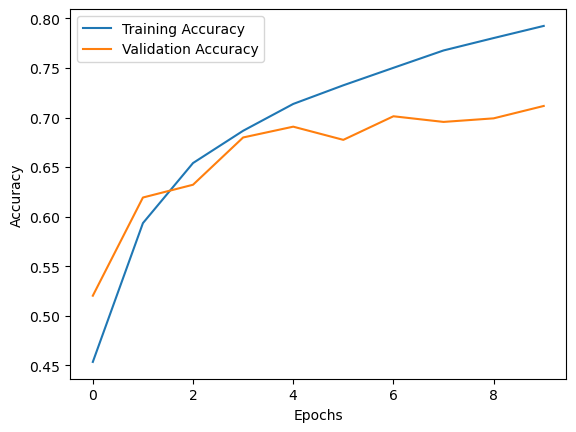

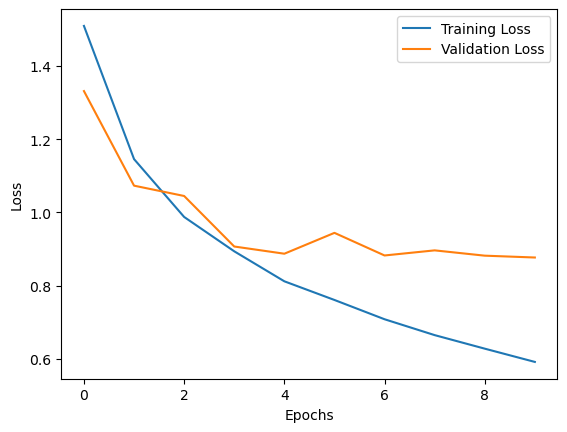

In [4]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build the CNN model
model = models.Sequential()

# First convolutional layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Second convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Third convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flatten the output for the dense layer
model.add(layers.Flatten())

# Fully connected (dense) layers
model.add(layers.Dense(64, activation='relu'))

# Output layer with 10 units (for 10 classes)
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary of the model
model.summary()

# Train the model
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8915 - loss: 0.3360 - val_accuracy: 0.9863 - val_loss: 0.0442
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9858 - loss: 0.0445 - val_accuracy: 0.9863 - val_loss: 0.0427
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9905 - loss: 0.0302 - val_accuracy: 0.9896 - val_loss: 0.0341
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9925 - loss: 0.0246 - val_accuracy: 0.9895 - val_loss: 0.0350
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9919 - val_loss: 0.0259
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9956 - loss: 0.0142 - val_accuracy: 0.9905 - val_loss: 0.0353
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9957 - loss: 0.0121 - val_accuracy: 0.9906 - val_loss: 0.0338
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9961 - loss: 0

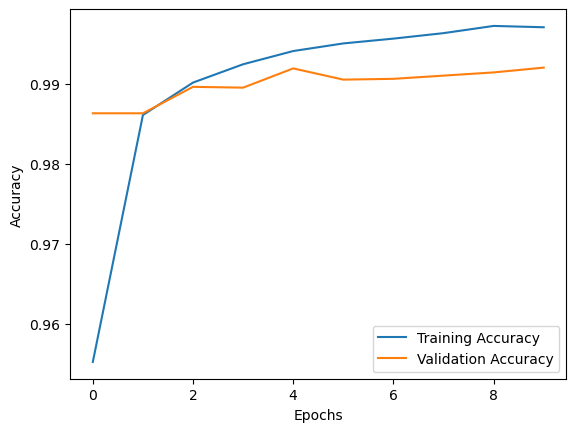

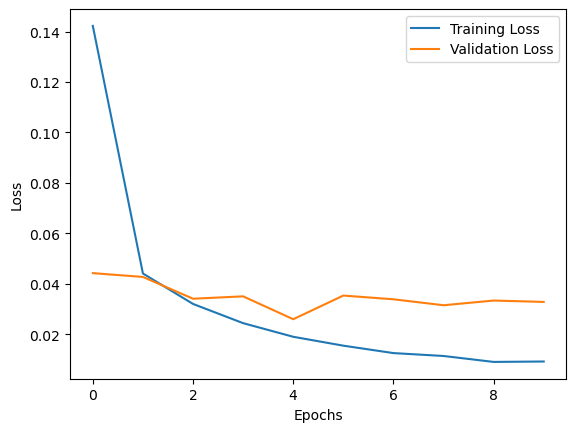

In [5]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape data to match CNN input (28x28x1) and normalize pixel values to be between 0 and 1
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

x_train, x_test = x_train / 255.0, x_test / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build the CNN model
model = models.Sequential()

# First convolutional layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# Second convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Third convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flatten the output for the dense layer
model.add(layers.Flatten())

# Fully connected (dense) layers
model.add(layers.Dense(64, activation='relu'))

# Output layer with 10 units (for 10 digits)
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary of the model
model.summary()

# Train the model
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


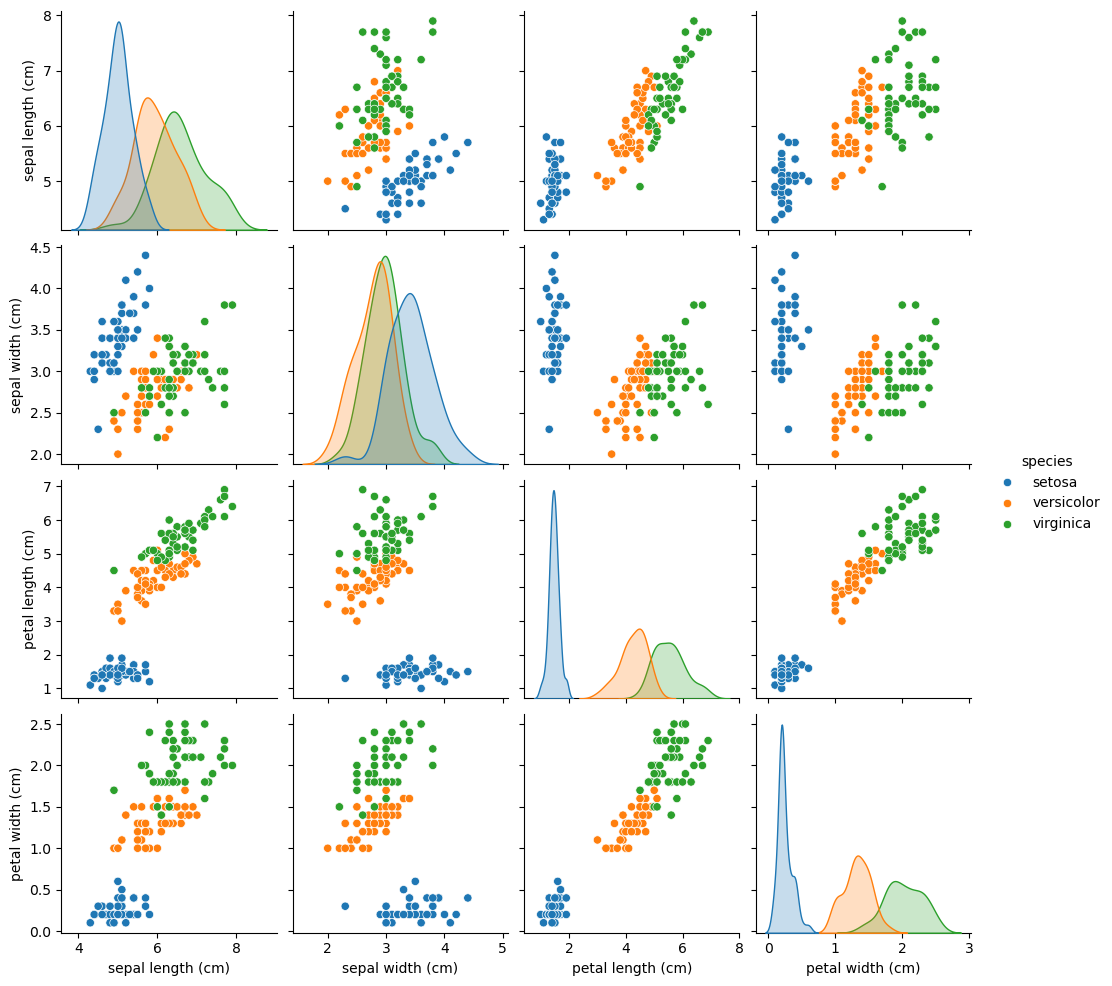

Random Forest Classifier:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Logistic Regression:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Support Vector Machine (SVM):
              precision    recall  f1-score   support

      setosa       1.00      1

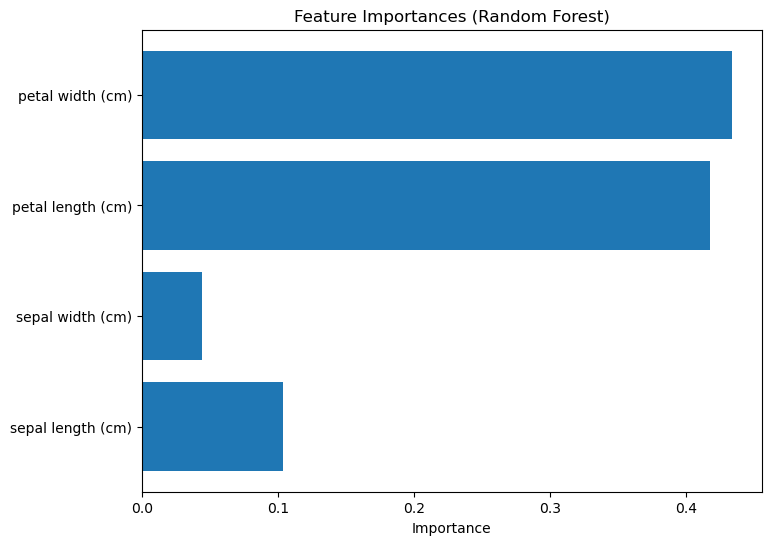

In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Load the Iris dataset from sklearn
from sklearn.datasets import load_iris
iris = load_iris()

# Convert the dataset into a pandas DataFrame for easier manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display the first few rows of the dataset
print(df.head())

# Visualize the data
sns.pairplot(df, hue="species")
plt.show()

# Split the data into features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the feature values using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions using the Random Forest model
rf_predictions = rf_model.predict(X_test_scaled)

# Evaluate the Random Forest model
print("Random Forest Classifier:")
print(classification_report(y_test, rf_predictions))
print(confusion_matrix(y_test, rf_predictions))

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_scaled, y_train)

# Make predictions using the Logistic Regression model
lr_predictions = lr_model.predict(X_test_scaled)

# Evaluate the Logistic Regression model
print("\nLogistic Regression:")
print(classification_report(y_test, lr_predictions))
print(confusion_matrix(y_test, lr_predictions))

# Model 3: Support Vector Machine (SVM)
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)

# Make predictions using the SVM model
svm_predictions = svm_model.predict(X_test_scaled)

# Evaluate the SVM model
print("\nSupport Vector Machine (SVM):")
print(classification_report(y_test, svm_predictions))
print(confusion_matrix(y_test, svm_predictions))

# Plot feature importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 6))
plt.title("Feature Importances (Random Forest)")
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.show()



In [8]:
import cv2

# Load the pre-trained Haar Cascade Classifiers for face and eye detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Capture video from webcam
cap = cv2.VideoCapture(0)  # 0 means the default webcam

while True:
    # Read the frame from the webcam
    ret, frame = cap.read()

    # Convert the frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw a rectangle around each face
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # Region of Interest (ROI) for eye detection within the detected face
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = frame[y:y + h, x:x + w]

        # Detect eyes within the face region
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

    # Display the resulting frame with face and eye detection
    cv2.imshow('Face and Eye Detection', frame)

    # Break the loop when 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close all OpenCV windows
cap.release()
cv2.destroyAllWindows()


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Accuracy: 100.00%
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


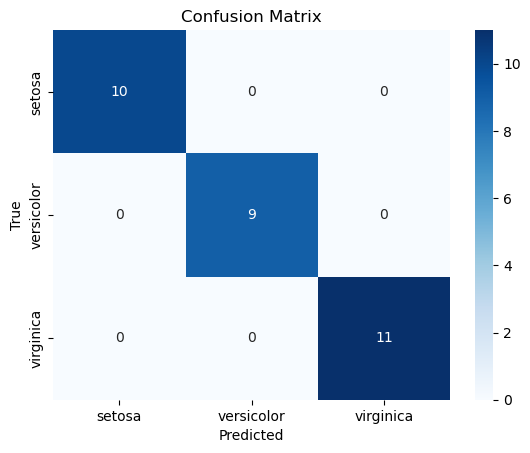

The predicted class for the new flower is: setosa


E:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# Step 2: Load the Iris dataset
from sklearn.datasets import load_iris
data = load_iris()

# Convert the dataset to a pandas DataFrame
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target

# Display the first few rows of the dataset
print(df.head())

# Step 3: Data Preprocessing
# Split the data into features (X) and target (y)
X = df.drop('target', axis=1)  # Features
y = df['target']  # Target

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Feature Scaling (Standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit and transform training data
X_test = scaler.transform(X_test)  # Transform test data

# Step 5: Train a Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Step 6: Make predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate the model
# 1. Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# 2. Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Step 8: Visualize the confusion matrix using seaborn
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 9: Make a new prediction (for example, an unseen flower)
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example: Sepal length=5.1, Sepal width=3.5, Petal length=1.4, Petal width=0.2
new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)
print(f"The predicted class for the new flower is: {data.target_names[prediction][0]}")


In [10]:
a=55
a

55

In [11]:
type(a)

int

In [12]:
b=4.4
b

4.4

In [13]:
b

4.4

In [14]:
b

4.4

In [15]:
type(b)

float

In [16]:
b

4.4

In [17]:
b

4.4

In [18]:
c={1,2,3,4}
c

{1, 2, 3, 4}

In [19]:
c

{1, 2, 3, 4}

In [20]:
c

{1, 2, 3, 4}

In [21]:
c

{1, 2, 3, 4}

In [22]:
type(c)

set

In [23]:
c

{1, 2, 3, 4}

In [24]:
d={12,14,"ai","ml"}
d

{12, 14, 'ai', 'ml'}

In [25]:
d.add(15)

In [26]:
d

{12, 14, 15, 'ai', 'ml'}

In [27]:
d.add("deeplearning")

In [28]:
d

{12, 14, 15, 'ai', 'deeplearning', 'ml'}

In [29]:
d.add("genai")

In [30]:
d

{12, 14, 15, 'ai', 'deeplearning', 'genai', 'ml'}

In [31]:
d.add("genaiml")
d

{12, 14, 15, 'ai', 'deeplearning', 'genai', 'genaiml', 'ml'}

In [32]:
for i in range(14):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13


In [33]:
i=0
while(i<15):
    print(i)
    i=i+1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14


In [39]:
a=int(input("enter the number"))
a
if(a>5):
    print("variable is greater")
elif(a==5):
    print("varaible is equal to 5")
else:
    print("variable is not greater")

enter the number 5


varaible is equal to 5


In [40]:

try:
    # Code that might raise an exception
    # For example, dividing by zero or accessing an invalid file
    result = 10 / 0  # This will raise a ZeroDivisionError
except ZeroDivisionError as e:
    # Code that handles the exception
    print(f"Error occurred: {e}")


Error occurred: division by zero


In [41]:
import math
print(math.floor(4.5))

4


In [42]:
# Using a for loop to print numbers from 1 to 5
for i in range(1, 6):
    print(i)


1
2
3
4
5


In [43]:
# Using a for loop to print each fruit in a list
fruits = ['apple', 'banana', 'cherry']
for fruit in fruits:
    print(fruit)


apple
banana
cherry


In [44]:
# Using a while loop to print numbers from 1 to 5
i = 1
while i <= 5:
    print(i)
    i += 1  # Increment i by 1 each time


1
2
3
4
5


In [45]:
fruits  = ['apple', 'Mango' , 'Banana']
for fruit in fruits:
    print(fruit)

apple
Mango
Banana


In [46]:
i=1
while i<= 6:
    print(i)
    i+=1

1
2
3
4
5
6


In [50]:
# Simple if-else program to check if a number is positive, negative, or zero

num = int(input("Enter a number: "))  # Take user input

if num > 0:
    print("The number is positive.")
elif num < 0:
    
    print("The number is negative.")
else:
    print("The number is zero.")


Enter a number:  12


The number is positive.


In [52]:
# Program to check if a number is even or odd

num = int(input("Enter a number: "))  # Take user input

if num % 2 == 0:
    print(f"{num} is an even number.")
else:
    print(f"{num} is an odd number.")


Enter a number:  15


15 is an odd number.


In [53]:
a=55
a

55

In [54]:
print(a)

55


In [55]:
b=4.5
b

4.5

In [ ]:
print(type

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
import json
import pickle
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
import random

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Load intents
with open('intents.json') as file:
    intents = json.load(file)

# Preprocess data
words = []
classes = []
documents = []
ignore_words = ['?', '!', '.', ',']

for intent in intents['intents']:
    for pattern in intent['patterns']:
        # Tokenize each word
        word_list = nltk.word_tokenize(pattern)
        words.extend(word_list)
        # Add to documents
        documents.append((word_list, intent['tag']))
        # Add to classes
        if intent['tag'] not in classes:
            classes.append(intent['tag'])

# Lemmatize and remove duplicates
words = [lemmatizer.lemmatize(w.lower()) for w in words if w not in ignore_words]
words = sorted(set(words))
classes = sorted(set(classes))

# Save words and classes
pickle.dump(words, open('words.pkl', 'wb'))
pickle.dump(classes, open('classes.pkl', 'wb'))

# Create training data
training = []
output_empty = [0] * len(classes)

for doc in documents:
    bag = []
    word_patterns = doc[0]
    word_patterns = [lemmatizer.lemmatize(w.lower()) for w in word_patterns]
    for w in words:
        bag.append(1) if w in word_patterns else bag.append(0)
    
    # Output is a "1" for the current tag and "0" for others
    output_row = list(output_empty)
    output_row[classes.index(doc[1])] = 1
    training.append([bag, output_row])

# Shuffle and convert to array
random.shuffle(training)
training = np.array(training, dtype=object)

# Split into X and y
train_x = list(training[:, 0])
train_y = list(training[:, 1])

# Build model
model = Sequential()
model.add(Dense(128, input_shape=(len(train_x[0]),), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(train_y[0]), activation='softmax'))

# Compile model
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

# Train model
model.fit(np.array(train_x), np.array(train_y), epochs=200, batch_size=5, verbose=1)
model.save('chatbot_model.h5')

print("Model created and saved")

# Load model and dependencies for chatbot
from tensorflow.keras.models import load_model
model = load_model('chatbot_model.h5')
words = pickle.load(open('words.pkl', 'rb'))
classes = pickle.load(open('classes.pkl', 'rb'))

def clean_up_sentence(sentence):
    sentence_words = nltk.word_tokenize(sentence)
    sentence_words = [lemmatizer.lemmatize(word.lower()) for word in sentence_words]
    return sentence_words

def bag_of_words(sentence, words):
    sentence_words = clean_up_sentence(sentence)
    bag = [0] * len(words)
    for s in sentence_words:
        for i, w in enumerate(words):
            if w == s:
                bag[i] = 1
    return np.array(bag)

def predict_class(sentence):
    bow = bag_of_words(sentence, words)
    res = model.predict(np.array([bow]))[0]
    ERROR_THRESHOLD = 0.25
    results = [[i, r] for i, r in enumerate(res) if r > ERROR_THRESHOLD]
    results.sort(key=lambda x: x[1], reverse=True)
    return_list = []
    for r in results:
        return_list.append({"intent": classes[r[0]], "probability": str(r[1])})
    return return_list

def get_response(intents_list, intents_json):
    tag = intents_list[0]['intent']
    for i in intents_json['intents']:
        if i['tag'] == tag:
            return random.choice(i['responses'])

print("Chatbot is ready to chat!\n")

while True:
    message = input("You: ")
    if message.lower() == "quit":
        break
    intents = predict_class(message)
    response = get_response(intents, intents)
    print(f"Chatbot: {response}")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


E:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7657 - loss: 0.6696
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8499 - loss: 0.4128
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8636 - loss: 0.3742
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8755 - loss: 0.3425
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8764 - loss: 0.3327
313/313 - 1s - 2ms/step - accuracy: 0.8726 - loss: 0.3593

Test accuracy: 0.8726000189781189
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


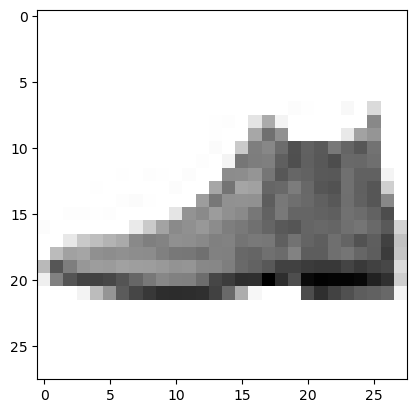

Predicted label: 9
Actual label: 9


In [1]:
#Artificial intelligence project
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Build the model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # Flatten the 28x28 images into 1D array
    layers.Dense(128, activation='relu'),  # Fully connected layer with 128 units
    layers.Dropout(0.2),  # Dropout to prevent overfitting
    layers.Dense(10, activation='softmax')  # Output layer with 10 units (for 10 classes)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(train_images, train_labels, epochs=5)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

# Make predictions on the test set
predictions = model.predict(test_images)

# Display the prediction for the first test image
plt.imshow(test_images[0], cmap=plt.cm.binary)
plt.show()

print(f'Predicted label: {np.argmax(predictions[0])}')
print(f'Actual label: {test_labels[0]}')


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


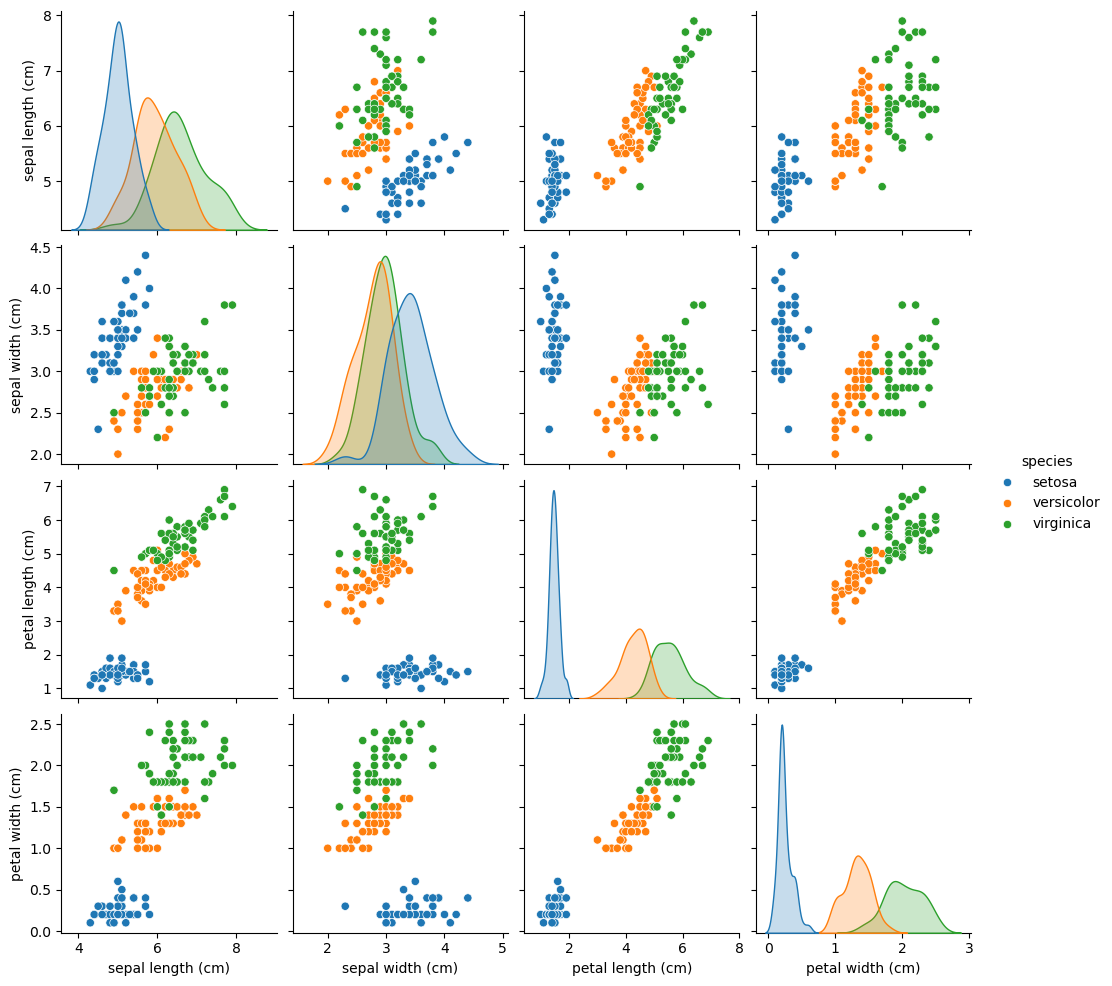

ValueError: could not convert string to float: 'setosa'

<Figure size 800x600 with 0 Axes>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.datasets import load_iris

# Load the Iris dataset from sklearn
data = load_iris()

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(data.data, columns=data.feature_names)
df['species'] = data.target

# Mapping numeric labels to species names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Show the first few rows of the dataset
print(df.head())

# Data Exploration: Pairplot
sns.pairplot(df, hue='species')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split the data into features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


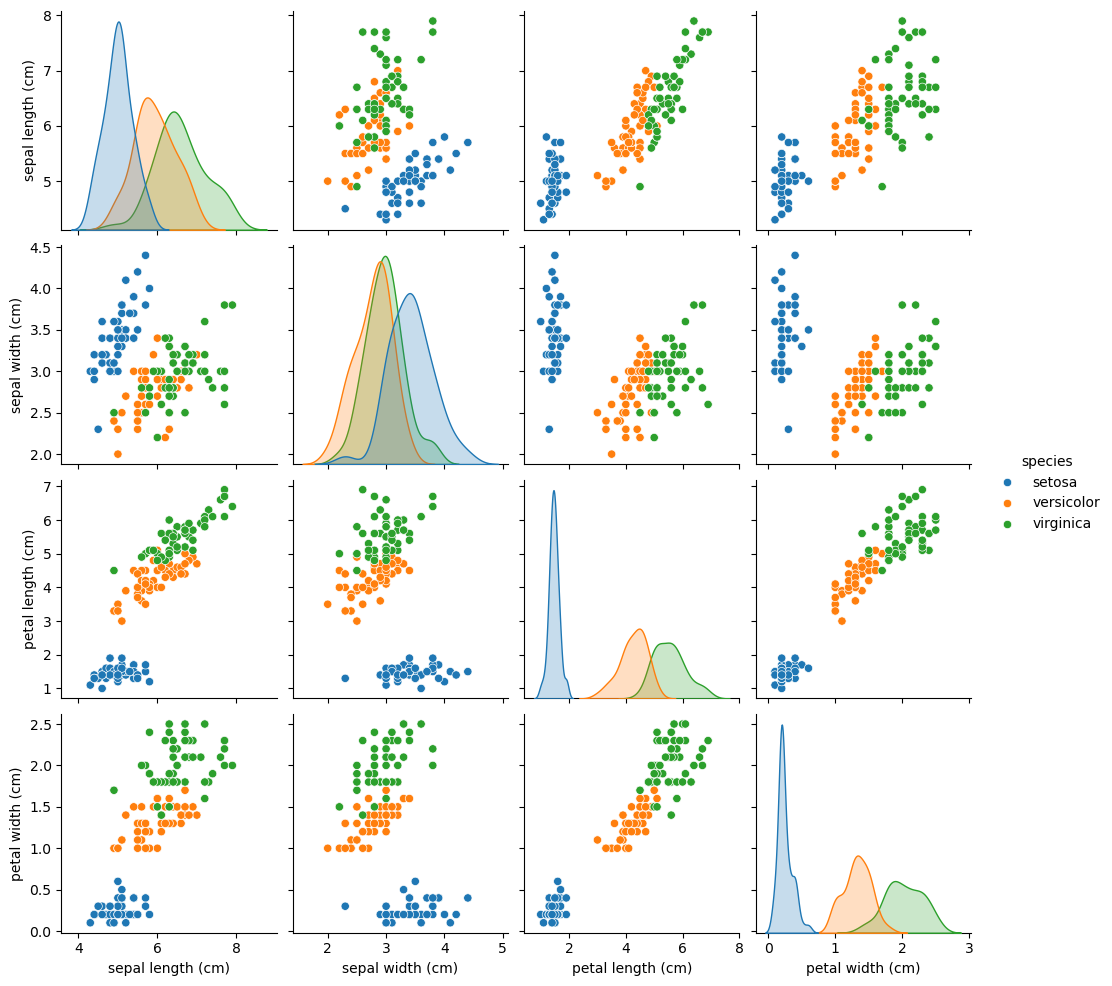

ValueError: could not convert string to float: 'setosa'

<Figure size 800x600 with 0 Axes>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.datasets import load_iris

# Load the Iris dataset from sklearn
data = load_iris()

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(data.data, columns=data.feature_names)
df['species'] = data.target

# Mapping numeric labels to species names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Show the first few rows of the dataset
print(df.head())

# Data Exploration: Pairplot
sns.pairplot(df, hue='species')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split the data into features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Dataset Head:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


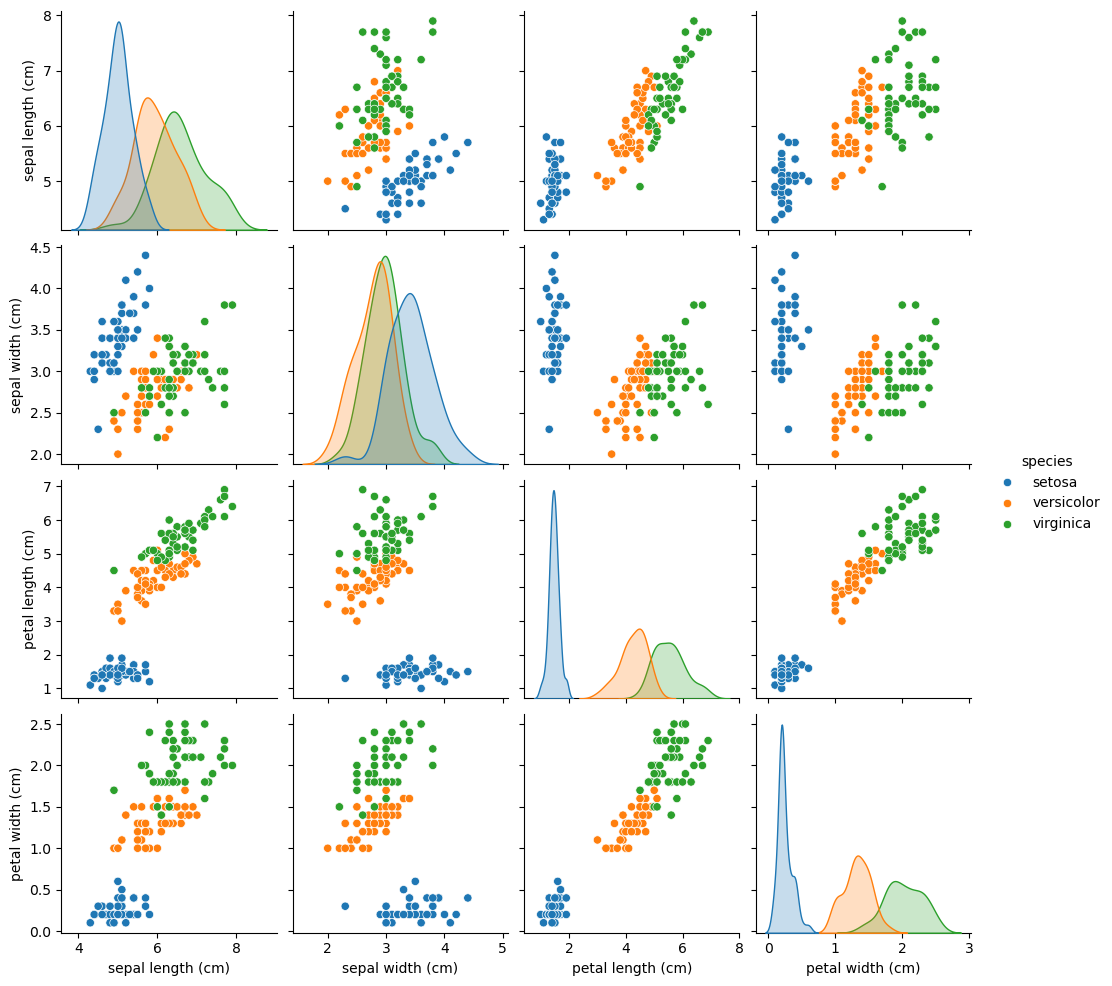

ValueError: could not convert string to float: 'setosa'

<Figure size 800x600 with 0 Axes>

In [4]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.datasets import load_iris

# 1. Load and Explore the Dataset
# Load the Iris dataset from sklearn
data = load_iris()

# Convert it to a DataFrame for easier manipulation
df = pd.DataFrame(data.data, columns=data.feature_names)
df['species'] = data.target

# Map numeric labels to species names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Show the first few rows of the dataset
print("Dataset Head:")
print(df.head())

# 2. Data Exploration and Visualization
# Pairplot to visualize relationships between features
sns.pairplot(df, hue='species')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# 3. Data Preprocessing
# Split the data into features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for algorithms like SVM, KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Train the Model (Random Forest Classifier)
# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# 5. Model Evaluation
# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. Load and Explore the Dataset
# Load the Iris dataset from sklearn
data = load_iris()

# Convert it into a Pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['species'] = data.target

# Map numeric target labels to species names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Show the first few rows
print(df.head())

# 2. Data Preprocessing
# Features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for algorithms like Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Train the Logistic Regression Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 4. Evaluate the Model
# Predict on the test set
y_pred = model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [6]:
import nltk
from nltk.chat.util import Chat, reflections

# 1. Create chatbot patterns and responses
pairs = [
    (r"hi|hello|hey", ["Hello!", "Hi there!", "Hey!"]),
    (r"how are you?", ["I'm doing well, thank you!", "I'm good, how about you?", "I'm fine!"]),
    (r"(.*) your name?", ["My name is Chatbot.", "I'm a chatbot, no specific name!"]),
    (r"quit", ["Goodbye!", "See you later!"]),
    (r"(.*)", ["Sorry, I didn't understand that. Can you please rephrase?"]),
]

# 2. Create chatbot using Chat class and patterns
def chatbot():
    print("Hello! I'm a simple chatbot. Type 'quit' to exit.")
    chatbot = Chat(pairs, reflections)
    chatbot.converse()

# 3. Start the chatbot
if __name__ == "__main__":
    chatbot()


Hello! I'm a simple chatbot. Type 'quit' to exit.


> hi


Hi there!


> hello


Hi there!


> what is your name?


I'm a chatbot, no specific name!


> quit


Goodbye!


In [7]:
a=55
a

55

In [8]:
type(a)

int

In [9]:
b=4.5
b

4.5

In [10]:
type(b)

float

In [11]:
c="string"
c

'string'

In [12]:
type(c)

str

In [13]:
d=[1,2,3,4,"aiml"]
d   

[1, 2, 3, 4, 'aiml']

In [14]:
d.append("dsai")
d

[1, 2, 3, 4, 'aiml', 'dsai']

In [15]:
d.append("aids")
d

[1, 2, 3, 4, 'aiml', 'dsai', 'aids']

In [16]:
e=(1,2,3,4)
e

(1, 2, 3, 4)

In [17]:
type(e)

tuple

In [18]:
e


(1, 2, 3, 4)

In [19]:
e.count

<function tuple.count(value, /)>

In [20]:
f={1:"apple",2:"mango",3:"Guava"}
f

{1: 'apple', 2: 'mango', 3: 'Guava'}

In [21]:
type(f)

dict

In [22]:
f.get(1)

'apple'

In [23]:
f.get("Guava")

In [24]:
f

{1: 'apple', 2: 'mango', 3: 'Guava'}

In [25]:
f.get(2)

'mango'

In [26]:
f.items()

dict_items([(1, 'apple'), (2, 'mango'), (3, 'Guava')])

In [27]:
f.keys()

dict_keys([1, 2, 3])

In [28]:
f.values()

dict_values(['apple', 'mango', 'Guava'])

In [29]:
f.items()

dict_items([(1, 'apple'), (2, 'mango'), (3, 'Guava')])

In [30]:
f.get(2)

'mango'

In [31]:
f

{1: 'apple', 2: 'mango', 3: 'Guava'}

In [32]:
f

{1: 'apple', 2: 'mango', 3: 'Guava'}

In [33]:
print(type(f))

<class 'dict'>


In [34]:
f

{1: 'apple', 2: 'mango', 3: 'Guava'}

In [35]:
type(f)

dict

In [36]:
for i in range(1,12):
    print(i)

1
2
3
4
5
6
7
8
9
10
11


In [37]:
i=0
while(i<16):
    print(i)
    i=i+1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


In [41]:
a=int(input("enter number"))
a
if(a>5):
    print("variable is greater")
elif(a==5):
    print("variable is equal to 5")
else:
    print("variable is not greater")

enter number 5


variable is equal to 5


In [42]:
a=55

In [43]:
b=44
a+b

99

In [44]:
a=45
b=45
a+b

90

In [45]:
b="string"
c=1.55
print(b+str(1.55))

string1.55


In [46]:
c=44
d=1.5
c+d

45.5

In [47]:
e="string"
e


'string'

In [48]:
type(e)

str

In [49]:
e.capitalize()

'String'

In [50]:
e.upper()

'STRING'

In [51]:
e.lower()

'string'

In [53]:
e.find()
e

NameError: name 's' is not defined